# Deterministic and noisy gradient flows

This notebook illustrates two particle representations of a flow in the same two-dimensional bimodal potential.  The target density is a Gaussian mixture

$$
\beta(x) = \sum_{r=1}^2 w_r\,\mathcal N(x;m_r,\Sigma_r),
$$

and the deterministic particles follow the gradient field $\nabla\log\beta$.  The noisy particles follow the same drift with an additional Brownian term.  The exported figure compares trajectories and empirical density snapshots, using the red-to-blue convention for time.


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


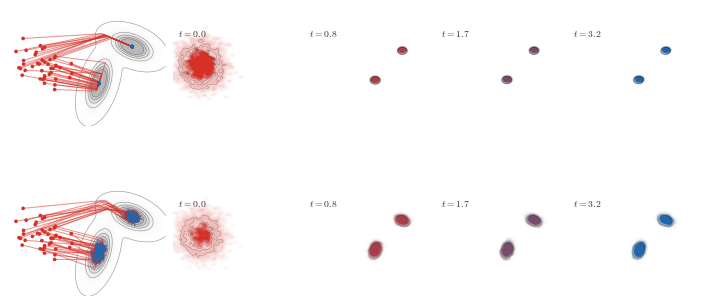

In [1]:

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from scipy.ndimage import gaussian_filter

ROOT = Path.cwd().resolve().parents[0]
if str(ROOT / "notebooks-figures") not in sys.path:
    sys.path.append(str(ROOT / "notebooks-figures"))
from figure_style import setup_matplotlib, figure_dir, save_pdf, remove_axes, RED, BLUE, VIOLET, interp_color

setup_matplotlib()
rng = np.random.default_rng(20260612)
name = "gradflow-deterministic-versus-noisy"
out_dir = figure_dir(name)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(exist_ok=True)

# Target Gaussian mixture and its score.
weights = np.array([0.52, 0.48])
means = np.array([[0.35, -0.28], [0.95, 0.38]])
Sigmas = np.array([
    [[0.12**2, 0.012], [0.012, 0.22**2]],
    [[0.19**2, -0.010], [-0.010, 0.13**2]],
])
invSigmas = np.linalg.inv(Sigmas)
dets = np.linalg.det(Sigmas)

xlim = (-1.25, 1.55)
ylim = (-1.05, 1.05)

def mixture_density(X):
    X = np.asarray(X)
    vals = np.zeros(X.shape[:-1])
    for w, m, S_inv, det in zip(weights, means, invSigmas, dets):
        d = X - m
        q = np.einsum('...i,ij,...j->...', d, S_inv, d)
        vals += w * np.exp(-0.5 * q) / (2 * np.pi * np.sqrt(det))
    return vals

def score_beta(X):
    X = np.asarray(X)
    num = np.zeros_like(X, dtype=float)
    den = np.zeros(X.shape[:-1], dtype=float)
    for w, m, S_inv, det in zip(weights, means, invSigmas, dets):
        d = X - m
        q = np.einsum('...i,ij,...j->...', d, S_inv, d)
        comp = w * np.exp(-0.5 * q) / (2 * np.pi * np.sqrt(det))
        den += comp
        num += comp[..., None] * (-(d @ S_inv.T))
    return num / np.maximum(den[..., None], 1e-300)

# Regular grid for backgrounds and density snapshots.
ng = 220
grid_x = np.linspace(*xlim, ng)
grid_y = np.linspace(*ylim, ng)
XX, YY = np.meshgrid(grid_x, grid_y)
GRID = np.stack([XX, YY], axis=-1)
target_Z = mixture_density(GRID)

T = 3.2
n_steps = 320
dt = T / n_steps
snapshot_ids = np.array([0, 80, 170, 320])
snapshot_times = snapshot_ids * dt
n_density = 2600
n_traj = 42
init_mean = np.array([-0.62, 0.04])
init_std = 0.24

X0_density = init_mean + init_std * rng.normal(size=(n_density, 2))
X0_traj = init_mean + init_std * rng.normal(size=(n_traj, 2))


def simulate(X0, noisy=False, noise=0.42):
    X = X0.copy()
    snapshots = {0: X.copy()}
    traj = [X.copy()]
    for k in range(1, n_steps + 1):
        drift = score_beta(X)
        X = X + dt * drift
        if noisy:
            X = X + noise * np.sqrt(dt) * rng.normal(size=X.shape)
        if k in snapshot_ids:
            snapshots[k] = X.copy()
        if X0.shape[0] == n_traj and (k % 4 == 0 or k == n_steps):
            traj.append(X.copy())
    return snapshots, np.asarray(traj)

snap_det, traj_det = simulate(X0_density, noisy=False)
_, traj_det_show = simulate(X0_traj, noisy=False)
snap_noisy, traj_noisy = simulate(X0_density, noisy=True)
_, traj_noisy_show = simulate(X0_traj, noisy=True)


def density_image(points, bins=180, sigma=2.2):
    H, _, _ = np.histogram2d(points[:, 0], points[:, 1], bins=bins, range=[xlim, ylim], density=True)
    H = gaussian_filter(H.T, sigma=sigma)
    return H

def make_time_cmap(t):
    c = interp_color(t)
    return LinearSegmentedColormap.from_list('time', [(1, 1, 1, 1), (*c, 0.22), (*c, 1.0)])


def draw_background(ax):
    q = np.quantile(target_Z, 0.975)
    ax.imshow(np.clip(target_Z, 0, q), extent=[*xlim, *ylim], origin='lower', cmap='Greys', alpha=0.28, vmin=0, vmax=q)
    levels = np.linspace(np.quantile(target_Z, 0.72), np.quantile(target_Z, 0.97), 5)
    ax.contour(XX, YY, target_Z, levels=levels, colors='#4a4a4a', linewidths=0.45, alpha=0.55)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
    remove_axes(ax)


def draw_trajectories(ax, traj):
    draw_background(ax)
    nT, nP, _ = traj.shape
    segs, cols = [], []
    for i in range(nP):
        pts = traj[:, i, :]
        segs.extend(np.stack([pts[:-1], pts[1:]], axis=1))
        cols.extend([(*interp_color(k / max(nT - 2, 1)), 0.54) for k in range(nT - 1)])
    lc = LineCollection(segs, colors=cols, linewidths=0.72, zorder=4)
    ax.add_collection(lc)
    ax.scatter(traj[0, :, 0], traj[0, :, 1], s=7, color=RED, edgecolor='none', zorder=5)
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=7, color=BLUE, edgecolor='none', zorder=5)


def draw_snapshots(fig, axes, snapshots):
    images = [density_image(snapshots[int(i)]) for i in snapshot_ids]
    vmax = np.quantile(np.concatenate([im.ravel() for im in images]), 0.985)
    for ax, H, sid, time in zip(axes, images, snapshot_ids, snapshot_times):
        tcol = sid / n_steps
        ax.imshow(np.clip(H, 0, vmax), extent=[*xlim, *ylim], origin='lower', cmap=make_time_cmap(tcol), vmin=0, vmax=vmax)
        levels = np.linspace(0.22 * vmax, 0.82 * vmax, 4)
        ax.contour(np.linspace(*xlim, H.shape[1]), np.linspace(*ylim, H.shape[0]), H, levels=levels, colors='#333333', linewidths=0.35, alpha=0.42)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect('equal')
        remove_axes(ax)
        ax.text(0.04, 0.92, f"$t={time:.1f}$", transform=ax.transAxes, ha='left', va='top', fontsize=7, color='#333333')

# Export four PDF panels: trajectory and density strip for each dynamics.
fig, ax = plt.subplots(figsize=(2.65, 2.15))
draw_trajectories(ax, traj_det_show)
save_pdf(fig, out_dir / 'deterministic-trajectories.pdf')
plt.close(fig)

fig, axes = plt.subplots(1, 4, figsize=(5.8, 1.55))
draw_snapshots(fig, axes, snap_det)
save_pdf(fig, out_dir / 'deterministic-snapshots.pdf')
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.65, 2.15))
draw_trajectories(ax, traj_noisy_show)
save_pdf(fig, out_dir / 'langevin-trajectories.pdf')
plt.close(fig)

fig, axes = plt.subplots(1, 4, figsize=(5.8, 1.55))
draw_snapshots(fig, axes, snap_noisy)
save_pdf(fig, out_dir / 'langevin-snapshots.pdf')
plt.close(fig)

# Notebook thumbnail: same layout as the LaTeX figure, without embedded titles.
fig = plt.figure(figsize=(8.8, 4.25))
gs = fig.add_gridspec(2, 5, width_ratios=[1.25, 1, 1, 1, 1], wspace=0.055, hspace=0.08)
ax = fig.add_subplot(gs[0, 0]); draw_trajectories(ax, traj_det_show)
axes = [fig.add_subplot(gs[0, k]) for k in range(1, 5)]; draw_snapshots(fig, axes, snap_det)
ax = fig.add_subplot(gs[1, 0]); draw_trajectories(ax, traj_noisy_show)
axes = [fig.add_subplot(gs[1, k]) for k in range(1, 5)]; draw_snapshots(fig, axes, snap_noisy)
fig.savefig(thumb_dir / f'{name}.png', dpi=180, bbox_inches='tight', pad_inches=0.03)
plt.show()
